# Gradient descent from scratch

Every neural network in this folder is trained with some variant of **gradient descent**: compute how the loss changes with respect to each parameter, then take a small step in the direction that decreases it,

$$\theta \leftarrow \theta - \eta \, \nabla_\theta L(\theta),$$

where $\eta$ is the **learning rate**. PyTorch computes the gradients automatically (**autograd**), so the whole training loop fits in a few lines.

This notebook builds intuition on two problems where the right answer is known:

1. minimizing a simple quadratic function, to see how the learning rate decides between slow convergence, oscillation and divergence;
2. fitting a polynomial with a linear model trained by gradient descent, to compare it with the exact least squares solution and to see why **feature scaling** matters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 100

## 1. Gradient descent on a quadratic bowl

We minimize

$$f(x, y) = \frac{x^2}{2} + 2y^2 ,$$

whose minimum is at the origin. The gradient is $\nabla f = (x, 4y)$, so one step of gradient descent multiplies $x$ by $(1 - \eta)$ and $y$ by $(1 - 4\eta)$. We let autograd compute the gradient, starting from $(-1000, -1000)$.

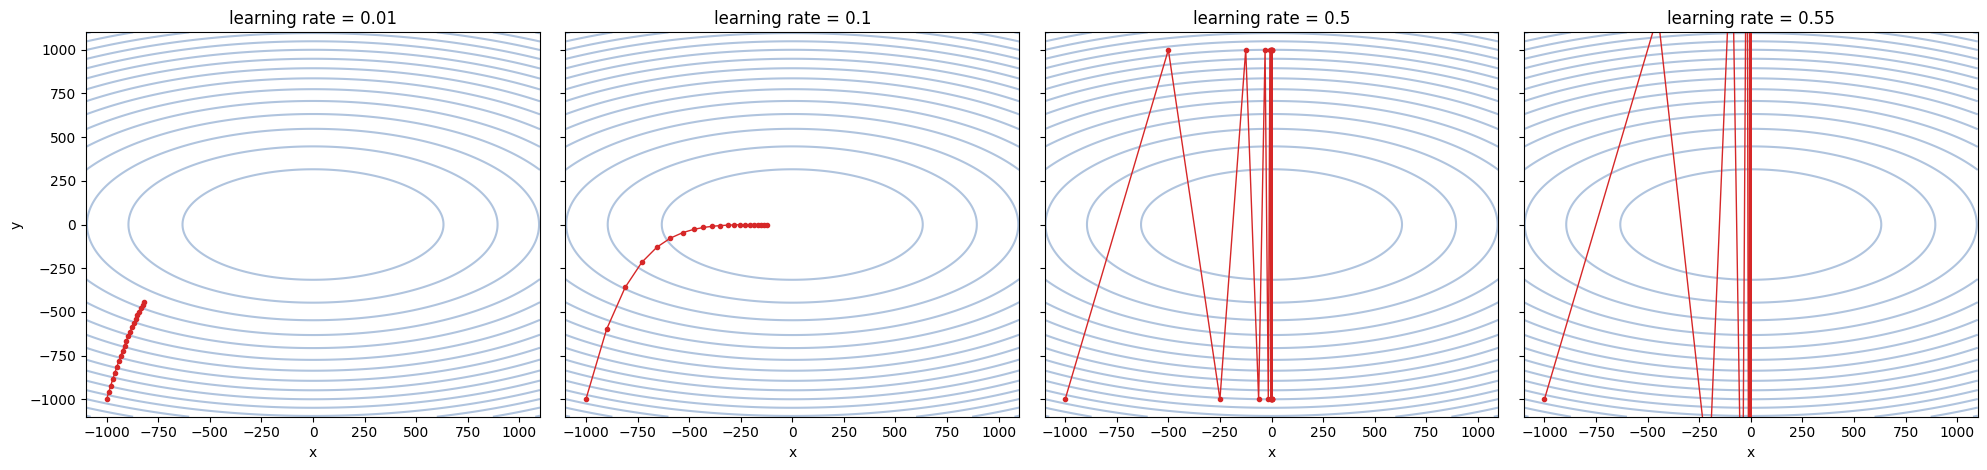

In [2]:
def gradient_descent(lr, steps=20, start=(-1000.0, -1000.0)):
    point = torch.tensor(start, requires_grad=True)
    weights = torch.tensor([0.5, 2.0])
    path = [point.detach().clone()]
    for _ in range(steps):
        loss = torch.dot(weights, point ** 2)     # f(x, y)
        loss.backward()                           # autograd fills point.grad
        with torch.no_grad():
            point -= lr * point.grad
            point.grad.zero_()
        path.append(point.detach().clone())
    return torch.stack(path).numpy()

grid = np.linspace(-1100, 1100, 200)
X, Y = np.meshgrid(grid, grid)
Z = X ** 2 / 2 + 2 * Y ** 2

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), sharey=True)
for ax, lr in zip(axes, [0.01, 0.1, 0.5, 0.55]):
    path = gradient_descent(lr)
    ax.contour(X, Y, Z, levels=15, colors="lightsteelblue")
    ax.plot(path[:, 0], path[:, 1], "o-", color="tab:red", ms=3, lw=1)
    ax.set(title=f"learning rate = {lr}", xlim=(-1100, 1100), ylim=(-1100, 1100), xlabel="x")
axes[0].set_ylabel("y")
fig.tight_layout()
plt.show()

- **$\eta = 0.01$**: every step is safe but tiny; after 20 steps we are still far from the minimum.
- **$\eta = 0.1$**: fast and smooth convergence. $y$ shrinks by a factor $0.6$ per step, $x$ by $0.9$, so the path first flattens $y$ and then slides along the $x$ direction.
- **$\eta = 0.5$**: $y$ is multiplied by $1 - 4 \cdot 0.5 = -1$ at every step, so it jumps between $+1000$ and $-1000$ forever, while $x$ converges.
- **$\eta = 0.55$**: the factor for $y$ becomes $-1.2$ and the iterates **diverge**.

Gradient descent on a quadratic converges only if $\eta < 2 / \lambda_{\max}$, where $\lambda_{\max}$ is the largest curvature (here 4, so $\eta < 0.5$). The steepest direction limits the learning rate, and the flattest direction then decides how long convergence takes. When curvatures differ a lot, the problem is **ill-conditioned** and gradient descent is slow. This is the key to the next section.

## 2. Fitting a polynomial with gradient descent

We generate noisy data from the polynomial

$$p(z) = 1 - z + 5z^2 - 0.1z^3 + \frac{z^4}{30}, \qquad z \in [-2, 2],$$

with Gaussian noise of standard deviation 0.5. The model is linear in the coefficients, so a single `nn.Linear` layer acting on the features $(1, z, z^2, z^3, z^4)$ can represent it exactly. Gradient descent should recover the true coefficients.

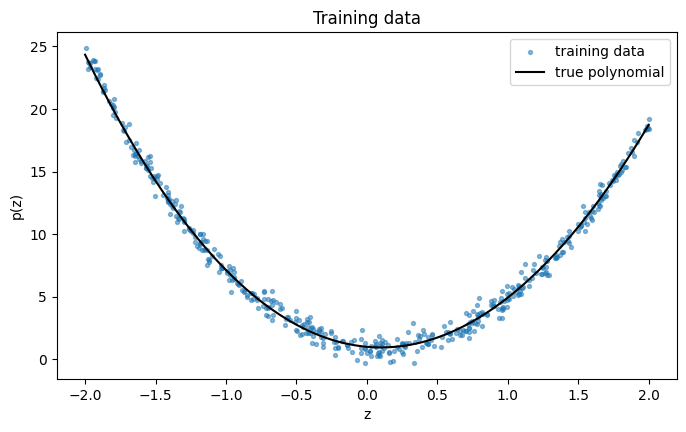

In [3]:
true_coeffs = torch.tensor([1.0, -1.0, 5.0, -0.1, 1 / 30])

def make_data(n, sigma=0.5, z_range=(-2.0, 2.0), seed=0):
    g = torch.Generator().manual_seed(seed)
    z = torch.rand(n, generator=g) * (z_range[1] - z_range[0]) + z_range[0]
    features = torch.stack([z ** k for k in range(5)], dim=1)
    y = features @ true_coeffs + sigma * torch.randn(n, generator=g)
    return z, features, y.unsqueeze(1)

z_train, X_train, y_train = make_data(500, seed=0)
z_val, X_val, y_val = make_data(500, seed=1)

grid_z = torch.linspace(-2, 2, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(z_train, y_train, s=8, alpha=0.5, label="training data")
ax.plot(grid_z, torch.stack([grid_z ** k for k in range(5)], 1) @ true_coeffs, color="black", label="true polynomial")
ax.set(xlabel="z", ylabel="p(z)", title="Training data")
ax.legend()
plt.show()

### The training loop

The four lines inside the loop are the core of every PyTorch training procedure: reset the gradients, compute the loss, back-propagate, update. Here each step uses the whole training set (full-batch gradient descent).

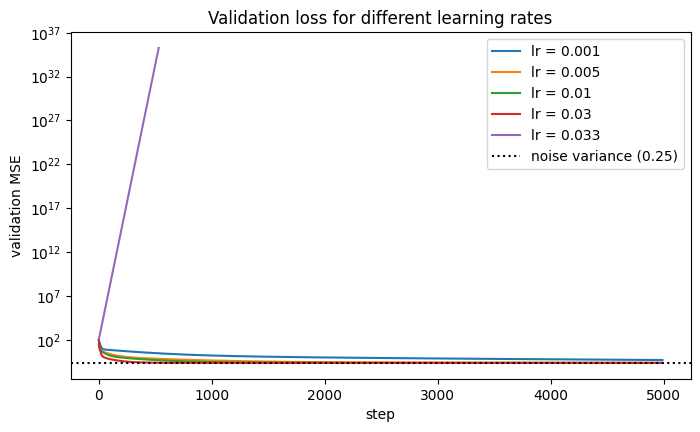

lr = 0.001  final validation MSE = 0.5424
lr = 0.005  final validation MSE = 0.2563
lr = 0.01   final validation MSE = 0.2546
lr = 0.03   final validation MSE = 0.2546
lr = 0.033  final validation MSE = nan


In [4]:
def train(X, y, X_val, y_val, lr, steps, record_every=1):
    model = nn.Linear(X.shape[1], 1, bias=False)   # the constant feature plays the role of the bias
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train": [], "val": [], "coeffs": []}
    for step in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        if step % record_every == 0:
            with torch.no_grad():
                history["train"].append(loss.item())
                history["val"].append(loss_fn(model(X_val), y_val).item())
                history["coeffs"].append(model.weight.detach().clone().squeeze())
    return model, history

results = {}
for lr in [0.001, 0.005, 0.01, 0.03, 0.033]:
    _, hist = train(X_train, y_train, X_val, y_val, lr=lr, steps=5000, record_every=10)
    results[lr] = hist

fig, ax = plt.subplots(figsize=(8, 4.5))
for lr, hist in results.items():
    ax.plot(np.arange(len(hist["val"])) * 10, hist["val"], label=f"lr = {lr}")
ax.axhline(0.25, color="black", ls=":", label="noise variance (0.25)")
ax.set(yscale="log", xlabel="step", ylabel="validation MSE", title="Validation loss for different learning rates")
ax.legend()
plt.show()
for lr, hist in results.items():
    print(f"lr = {lr:<6} final validation MSE = {hist['val'][-1]:.4g}")

With a learning rate of 0.033 the loss explodes, while 0.03 converges nicely: the threshold is sharp. Section 1 tells us where it lies. For the mean squared error the curvature is given by the matrix $H = \frac{2}{n} X^\top X$, and gradient descent is stable only for $\eta < 2 / \lambda_{\max}(H)$:

In [5]:
H = 2 * X_train.T @ X_train / len(X_train)
eigenvalues = torch.linalg.eigvalsh(H)
print(f"largest curvature: {eigenvalues.max():.1f}, smallest: {eigenvalues.min():.3f}")
print(f"largest stable learning rate: 2 / lambda_max = {2 / eigenvalues.max():.4f}")

largest curvature: 62.9, smallest: 0.172
largest stable learning rate: 2 / lambda_max = 0.0318


The feature $z^4$ reaches values up to 16, which makes the loss surface very steep in some directions and limits the learning rate to about 0.032. Among the stable rates, the larger ones reach the **noise floor** within the 5,000 steps: since the data contain noise with variance 0.25, no model can do better than a validation MSE of about 0.25. The smallest rate is still far from it.

### Did we recover the coefficients?

The linear model also has an exact solution, ordinary least squares, which we can compare with:

In [6]:
best_lr = 0.03
model, history = train(X_train, y_train, X_val, y_val, lr=best_lr, steps=20000, record_every=20)
ols = torch.linalg.lstsq(X_train, y_train).solution.squeeze()

import pandas as pd
pd.DataFrame({
    "true": true_coeffs.numpy(),
    "least squares": ols.numpy(),
    "gradient descent (20,000 steps)": model.weight.detach().squeeze().numpy(),
}, index=["1", "z", "z^2", "z^3", "z^4"]).round(4)

,true,least squares,"gradient descent (20,000 steps)"
1,1.0000,1.0223,1.0223
z,-1.0000,-1.0034,-1.0034
z^2,5.0000,4.8956,4.8956
z^3,-0.1000,-0.1103,-0.1102
z^4,0.0333,0.0722,0.0722


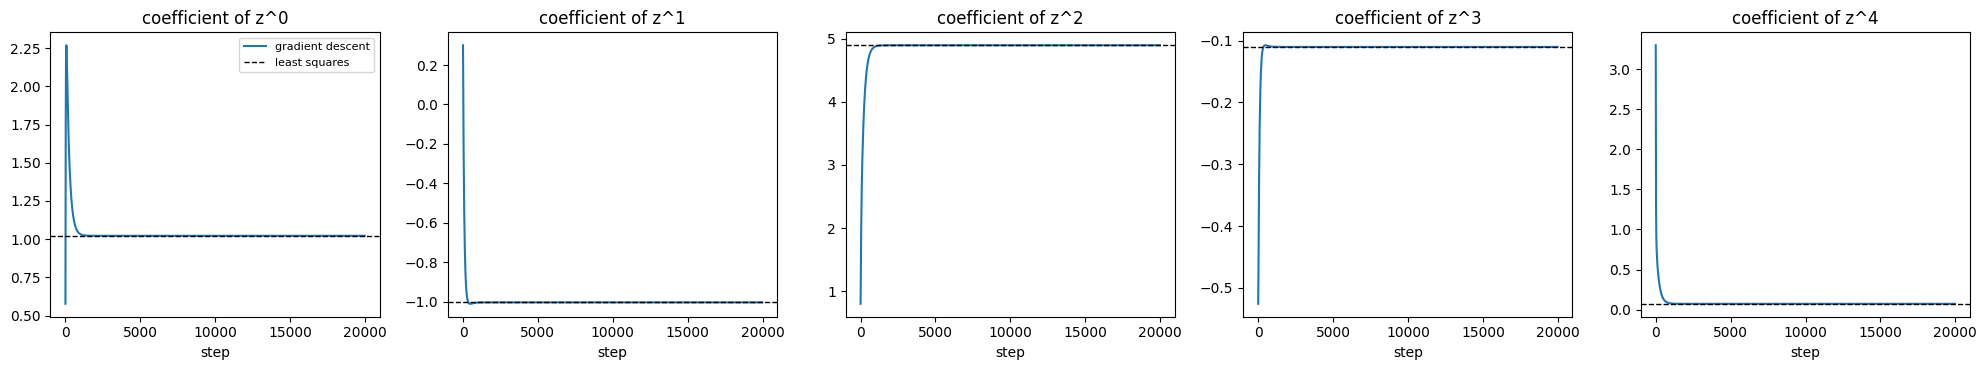

In [7]:
coeffs = torch.stack(history["coeffs"]).numpy()
steps = np.arange(len(coeffs)) * 20
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for k, ax in enumerate(axes):
    ax.plot(steps, coeffs[:, k], label="gradient descent")
    ax.axhline(ols[k], color="black", ls="--", lw=1, label="least squares")
    ax.set(title=f"coefficient of z^{k}", xlabel="step")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

Gradient descent converges to the least squares solution, which in turn is close to the true coefficients (the small differences are due to noise). But the coefficients converge at different speeds: the odd powers $z$ and $z^3$ settle within a few hundred steps, while the even powers $1, z^2, z^4$ need one to two thousand. The features $1, z^2, z^4$ are strongly correlated on $[-2, 2]$ and have very different scales, so the loss surface is a long, narrow valley: exactly the ill-conditioned situation of section 1.

### Standardizing the features

The standard fix is to **standardize** each feature (except the constant) to mean 0 and standard deviation 1 before training. The model is the same; only the parametrization changes, and the coefficients can be mapped back afterwards.

condition number of X^T X, raw features:          365
condition number of X^T X, standardized features: 46
largest stable learning rate, standardized features: 0.504


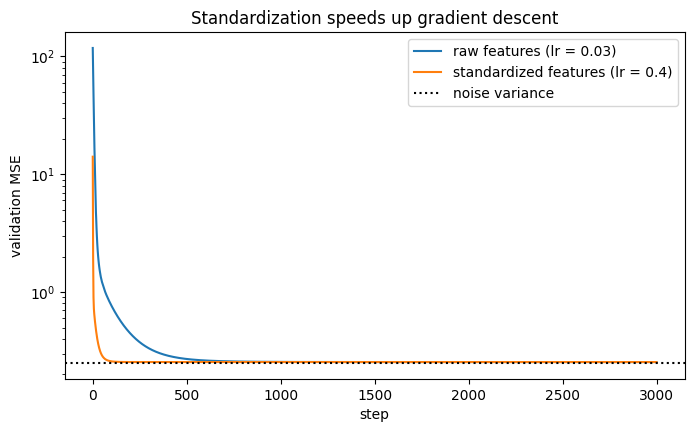

In [8]:
mean, std = X_train[:, 1:].mean(0), X_train[:, 1:].std(0)
standardize = lambda X: torch.cat([X[:, :1], (X[:, 1:] - mean) / std], dim=1)
Xs_train, Xs_val = standardize(X_train), standardize(X_val)

print(f"condition number of X^T X, raw features:          {torch.linalg.cond(X_train.T @ X_train):.0f}")
print(f"condition number of X^T X, standardized features: {torch.linalg.cond(Xs_train.T @ Xs_train):.0f}")

H_std = 2 * Xs_train.T @ Xs_train / len(Xs_train)
print(f"largest stable learning rate, standardized features: {2 / torch.linalg.eigvalsh(H_std).max():.3f}")

_, hist_raw = train(X_train, y_train, X_val, y_val, lr=0.03, steps=3000)
_, hist_std = train(Xs_train, y_train, Xs_val, y_val, lr=0.4, steps=3000)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hist_raw["val"], label="raw features (lr = 0.03)")
ax.plot(hist_std["val"], label="standardized features (lr = 0.4)")
ax.axhline(0.25, color="black", ls=":", label="noise variance")
ax.set(yscale="log", xlabel="step", ylabel="validation MSE", title="Standardization speeds up gradient descent")
ax.legend()
plt.show()

Standardization reduces the condition number by a factor of about 8, allows a learning rate more than ten times larger, and reaches the noise floor in about 100 steps instead of about 1,000. This is why inputs are almost always normalized before training a neural network, and why layers such as batch normalization (used in the CNN notebook) help.

### What happens with little or very noisy data?

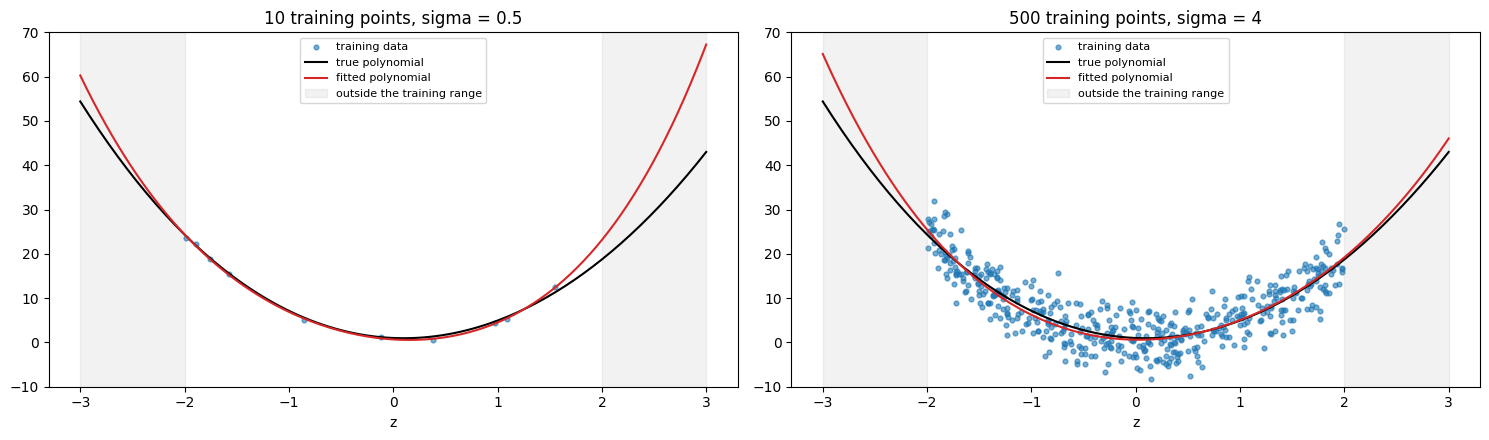

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
scenarios = [("10 training points, sigma = 0.5", 10, 0.5), ("500 training points, sigma = 4", 500, 4.0)]
for ax, (title, n, sigma) in zip(axes, scenarios):
    z, X, y = make_data(n, sigma=sigma, seed=3)
    coef = torch.linalg.lstsq(X, y).solution.squeeze()
    wide = torch.linspace(-3, 3, 200)
    wide_X = torch.stack([wide ** k for k in range(5)], 1)
    ax.scatter(z, y, s=12, alpha=0.6, label="training data")
    ax.plot(wide, wide_X @ true_coeffs, color="black", label="true polynomial")
    ax.plot(wide, wide_X @ coef, color="tab:red", label="fitted polynomial")
    ax.axvspan(-3, -2, color="grey", alpha=0.1)
    ax.axvspan(2, 3, color="grey", alpha=0.1, label="outside the training range")
    ax.set(title=title, xlabel="z", ylim=(-10, 70))
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Even with the correct model, the estimates degrade with **few observations** or **heavy noise**. Inside the training range the fitted curve stays reasonable, but **outside** it the errors in the high-order coefficients are amplified by large powers of $z$ and the curve departs quickly from the truth. A model is only reliable where it has seen data.

## Summary

- Gradient descent repeats one step: compute the gradient (autograd does it) and move against it, scaled by the learning rate.
- The learning rate must be smaller than $2 / \lambda_{\max}$; too small is slow, too large oscillates or diverges.
- When the curvature differs a lot between directions (**ill-conditioning**), convergence is slow. Polynomial features on an unscaled input are a typical example.
- **Standardizing the inputs** fixes the conditioning and speeds up training dramatically.
- Gradient descent on a linear model converges to the least squares solution; its accuracy is still limited by noise, sample size, and the range of the training data.